In [1]:
import pandas as pd 
import numpy as np

In [2]:
df1=pd.read_csv("C:\\Users\\DELL\\Downloads\\35. sales_data.csv")

In [3]:
df=df1.copy()

In [4]:
df.head().T

,0,1,2,3,4
order_id,AG-2011-2040,IN-2011-47883,HU-2011-1220,IT-2011-3647632,IN-2011-47883
order_date,1/1/2011,1/1/2011,1/1/2011,1/1/2011,1/1/2011
ship_date,1/6/2011,1/8/2011,1/5/2011,1/5/2011,1/8/2011
ship_mode,Standard Class,Standard Class,Second Class,Second Class,Standard Class
customer_name,Toby Braunhardt,Joseph Holt,Annie Thurman,Eugene Moren,Joseph Holt
segment,Consumer,Consumer,Consumer,Home Office,Consumer
state,Constantine,New South Wales,Budapest,Stockholm,New South Wales
country,Algeria,Australia,Hungary,Sweden,Australia
market,Africa,APAC,EMEA,EU,APAC
region,Africa,Oceania,EMEA,North,Oceania


In [5]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [6]:
df.shape

(51290, 21)

In [7]:
df.isna().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["sales"].apply(type).value_counts()

sales
<class 'str'>    51290
Name: count, dtype: int64

In [10]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [11]:
df["sales"]=pd.to_numeric(
    df["sales"].astype(str).str.replace(",","")
)

In [12]:
df["order_date"]=pd.to_datetime(df["order_date"])
df["ship_date"]=pd.to_datetime(df["ship_date"])



In [13]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [14]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [15]:
df["ship_mode"].unique()

array(['Standard Class', 'Second Class', 'Same Day', 'First Class'],
      dtype=object)

In [16]:
df["segment"].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [17]:
df["market"].unique()

array(['Africa', 'APAC', 'EMEA', 'EU', 'Canada', 'LATAM', 'US'],
      dtype=object)

In [18]:
df["region"].unique()

array(['Africa', 'Oceania', 'EMEA', 'North', 'Canada', 'Southeast Asia',
       'Central', 'South', 'Caribbean', 'North Asia', 'East', 'West',
       'Central Asia'], dtype=object)

In [19]:
df["category"].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [20]:
df["sub_category"].unique()


array(['Storage', 'Supplies', 'Paper', 'Furnishings', 'Machines',
       'Appliances', 'Copiers', 'Chairs', 'Tables', 'Bookcases', 'Phones',
       'Accessories', 'Labels', 'Art', 'Envelopes', 'Fasteners',
       'Binders'], dtype=object)

In [21]:
df["sales"].describe()

count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

In [22]:
print(df["sales"].value_counts(dropna=False))

sales
13      589
11      550
14      527
19      523
17      520
       ... 
1566      1
1501      1
2834      1
3802      1
1831      1
Name: count, Length: 2246, dtype: int64


In [23]:
df[df["sales"] == 0]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
40017,US-2014-102288,2014-06-20,2014-06-24,Standard Class,Zuschuss Carroll,Consumer,Texas,United States,US,Central,...,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0,1,0.8,-1.11,0.01,Medium,2014


In [24]:
df[df["sales"]==0]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
40017,US-2014-102288,2014-06-20,2014-06-24,Standard Class,Zuschuss Carroll,Consumer,Texas,United States,US,Central,...,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0,1,0.8,-1.11,0.01,Medium,2014


In [25]:
df[df["sales"] == 0][["sales", "quantity", "discount", "profit", "shipping_cost"]]

,sales,quantity,discount,profit,shipping_cost
40017,0,1,0.8,-1.11,0.01


In [26]:
(df["sales"]==0).sum()

np.int64(1)

In [27]:
df["quantity"].describe()

count    51290.000000
mean         3.476545
std          2.278766
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: quantity, dtype: float64

In [28]:
df["discount"].describe()

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: discount, dtype: float64

In [29]:
df["profit"].describe()

count    51290.000000
mean        28.641740
std        174.424113
min      -6599.978000
25%          0.000000
50%          9.240000
75%         36.810000
max       8399.976000
Name: profit, dtype: float64

In [30]:
(df["profit"]==-6599.978000).sum()

np.int64(1)

In [31]:
df[df["profit"] == -6599.978]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
31884,CA-2013-108196,2013-11-26,2013-12-03,Standard Class,Cindy Stewart,Consumer,Ohio,United States,US,East,...,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4500,5,0.7,-6599.978,451.63,Low,2013


In [32]:
(df["profit"] < 0).sum()

np.int64(12543)

In [33]:
df["shipping_cost"].describe()

count    51290.000000
mean        26.375915
std         57.296804
min          0.000000
25%          2.610000
50%          7.790000
75%         24.450000
max        933.570000
Name: shipping_cost, dtype: float64

In [34]:
(df["shipping_cost"]==0).sum()

np.int64(2)

In [35]:
df[df["shipping_cost"]==0]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
9827,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,Ross Baird,Home Office,S?o Paulo,Brazil,LATAM,South,...,Office Supplies,Binders,"Acco Index Tab, Economy",13,2,0.0,2.4,0.0,Medium,2012
11846,MX-2012-134460,2012-05-22,2012-05-26,Second Class,Mick Crebagga,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61,3,0.0,1.8,0.0,High,2012


In [36]:
df["year"].describe()

count    51290.000000
mean      2012.777208
std          1.098931
min       2011.000000
25%       2012.000000
50%       2013.000000
75%       2014.000000
max       2014.000000
Name: year, dtype: float64

In [37]:
df.shape
df.dtypes
df.isna().sum()
df.duplicated().sum()
df.shape

(51290, 21)

In [38]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

In [39]:
df.isna().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.shape

(51290, 21)

In [42]:
cat_cols = ["country", "state", "market", "region", "segment",
            "category", "sub_category", "ship_mode", "order_priority"]

In [43]:
df["country"].unique()

array(['Algeria', 'Australia', 'Hungary', 'Sweden', 'Canada',
       'New Zealand', 'Iraq', 'Philippines', 'United Kingdom', 'Malaysia',
       'Guatemala', 'Iran', 'Thailand', 'Tanzania', 'Brazil', 'Mexico',
       'Cuba', 'France', 'United States', 'Japan', 'Sudan', 'Taiwan',
       'Indonesia', 'Vietnam', 'Angola', 'China', 'Mozambique', 'Lebanon',
       'Singapore', 'Netherlands', 'Nigeria', 'Egypt', 'Venezuela',
       'South Africa', 'Spain', 'India', 'Turkey', 'Austria', 'Italy',
       'Germany', 'Nicaragua', 'Dominican Republic', 'El Salvador',
       'Denmark', 'Saudi Arabia', 'Zambia', 'Myanmar (Burma)', 'Russia',
       'Mongolia', 'Belgium', 'Kenya', 'Colombia', 'Estonia',
       'Madagascar', 'Portugal', 'Morocco', 'Sierra Leone', 'Norway',
       'Central African Republic', 'Czech Republic', 'Benin',
       'Bangladesh', 'Panama', 'Chile', 'South Korea', 'Switzerland',
       'Moldova', 'Uganda', 'Zimbabwe', 'Niger', 'Senegal', 'Hong Kong',
       'Democratic Republic o

In [44]:
df["country"].nunique()

147

In [45]:
df["country"].value_counts()

country
United States    9994
Australia        2837
France           2827
Mexico           2644
Germany          2065
                 ... 
Burundi             2
Chad                2
Eritrea             2
Bahrain             2
South Sudan         2
Name: count, Length: 147, dtype: int64

In [46]:
df["country"].str.lower().nunique()

147

In [47]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [48]:
df["state"].nunique()

1094

In [49]:
df["state"].str.lower().nunique()

1094

In [50]:
df["market"].nunique()

7

In [51]:
df["market"].str.lower().nunique()

7

In [52]:
df["region"].nunique()

13

In [53]:
df["region"].str.lower().nunique()

13

In [54]:
df["segment"].str.lower().nunique()

3

In [55]:
df["segment"].nunique()

3

In [56]:
df["category"].nunique()

3

In [57]:
df["category"].str.lower().nunique()

3

In [58]:
df["sub_category"].nunique()

17

In [59]:
df["sub_category"].str.lower().nunique()


17

In [60]:
df["ship_mode"].nunique()

4

In [61]:
df["ship_mode"].str.lower().nunique()

4

In [62]:
df["order_priority"].nunique()

4

In [63]:
df["order_priority"].nunique()

4

In [64]:
df["order_priority"].str.lower().nunique()

4

In [65]:
df["order_id"].nunique()

25035

In [66]:
df["order_id"].isna().sum()

np.int64(0)

In [67]:
df["order_id"].duplicated().sum()

np.int64(26255)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df["product_id"].duplicated().sum()

np.int64(40998)

In [70]:
df["product_id"].isna().sum()

np.int64(0)

In [71]:
df["product_id"].nunique()

10292

In [72]:
(df["ship_date"] < df["order_date"]).sum()

np.int64(0)

# EDA



In [73]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

In [74]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df.discount.max()

0.85

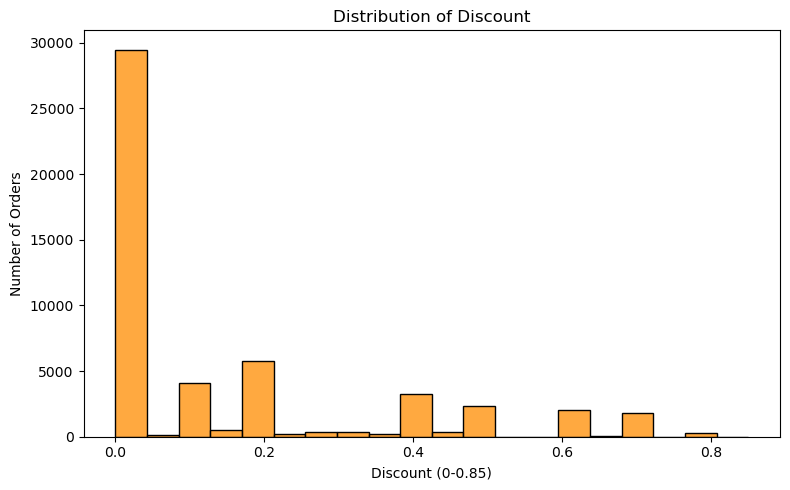

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(df["discount"], bins=20, color="darkorange")

plt.title("Distribution of Discount")
plt.xlabel("Discount (0-0.85)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [78]:
df.profit.max()

8399.976

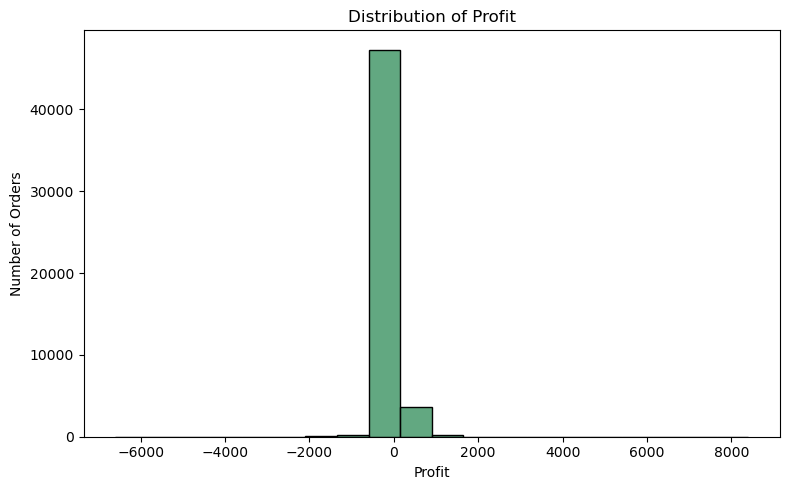

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(df["profit"],bins=20,color="seagreen")
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

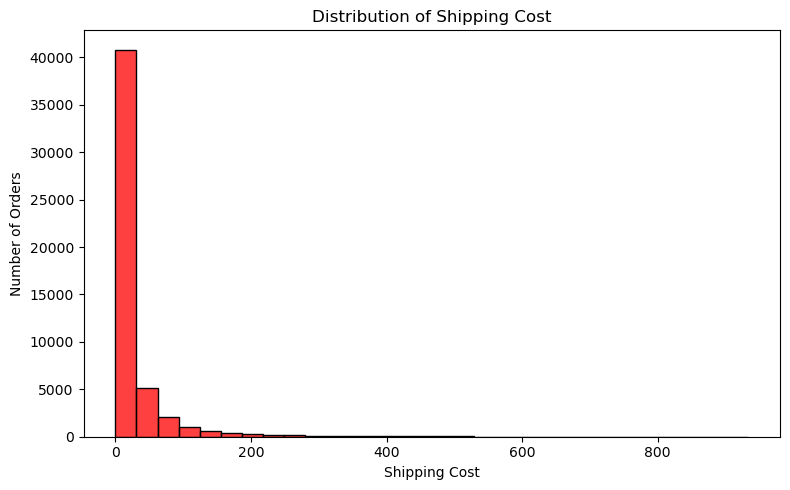

In [80]:
plt.figure(figsize=(8,5))
sns.histplot(df["shipping_cost"],bins=30,color="red")
plt.title("Distribution of Shipping Cost")
plt.xlabel("Shipping Cost")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

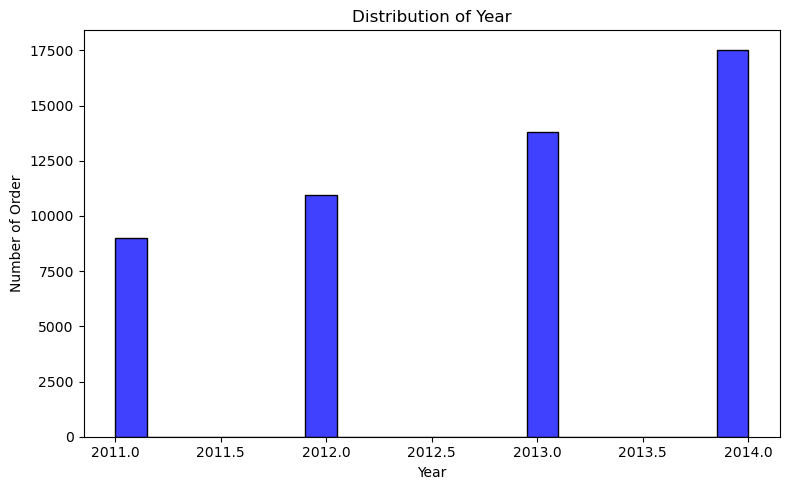

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df["year"],bins=20,color="blue")
plt.title("Distribution of Year")
plt.xlabel("Year")
plt.ylabel("Number of Order")
plt.tight_layout()
plt.show()

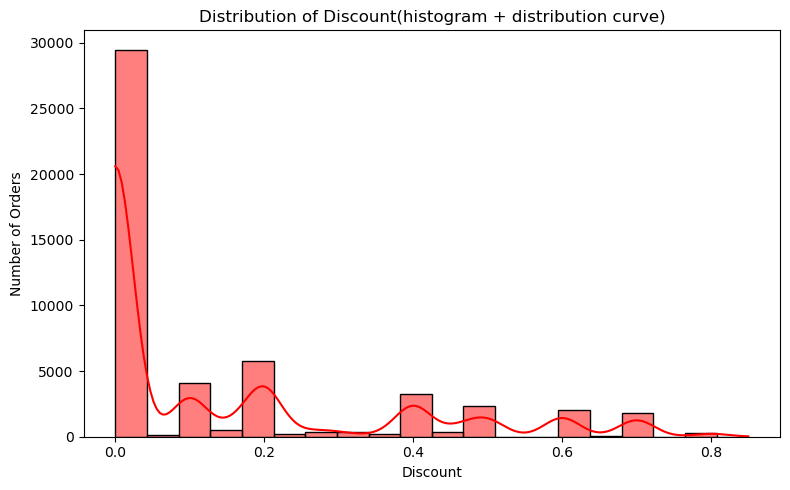

In [82]:
plt.figure(figsize=(8,5))
sns.histplot(df["discount"],bins=20,kde=True,color="red")
plt.title("Distribution of Discount(histogram + distribution curve)")
plt.xlabel("Discount")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

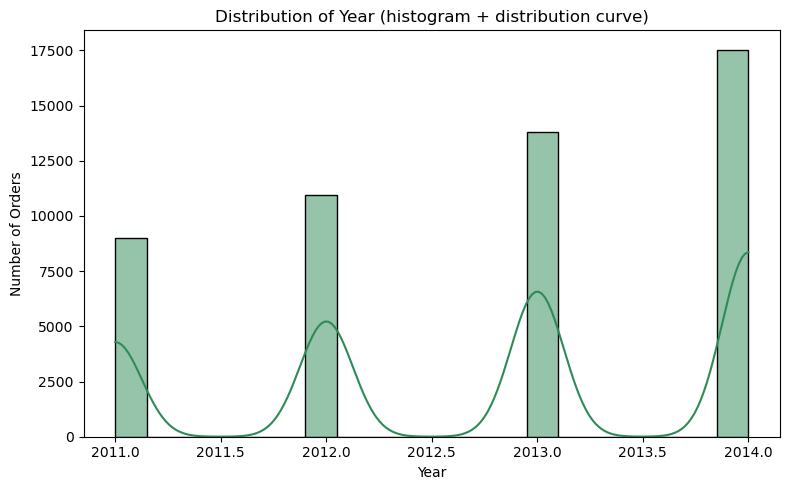

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(df["year"],bins=20,kde=True,color="seagreen")
plt.title("Distribution of Year (histogram + distribution curve)")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

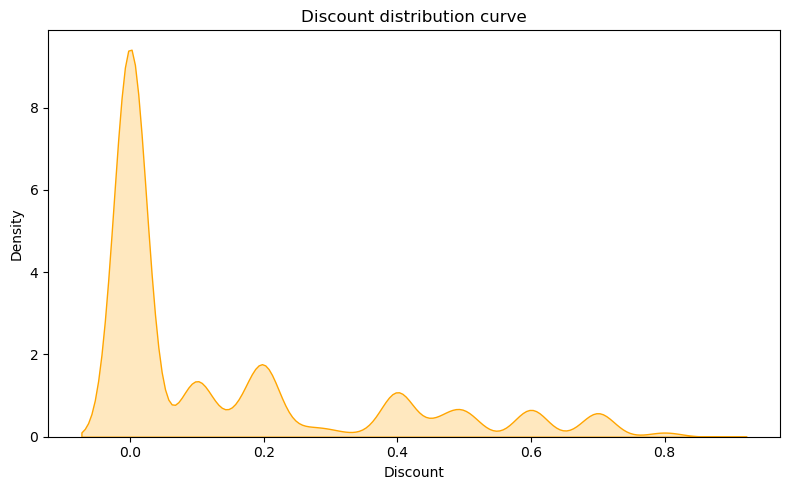

In [84]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["discount"],fill=True,color="orange")
plt.title("Discount distribution curve")
plt.xlabel("Discount")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

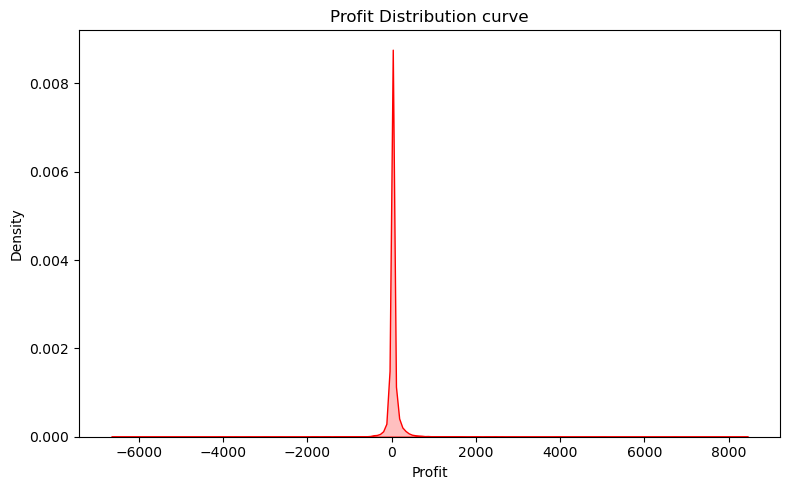

In [85]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["profit"],fill=True,color="red")
plt.title("Profit Distribution curve")
plt.xlabel("Profit")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [86]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

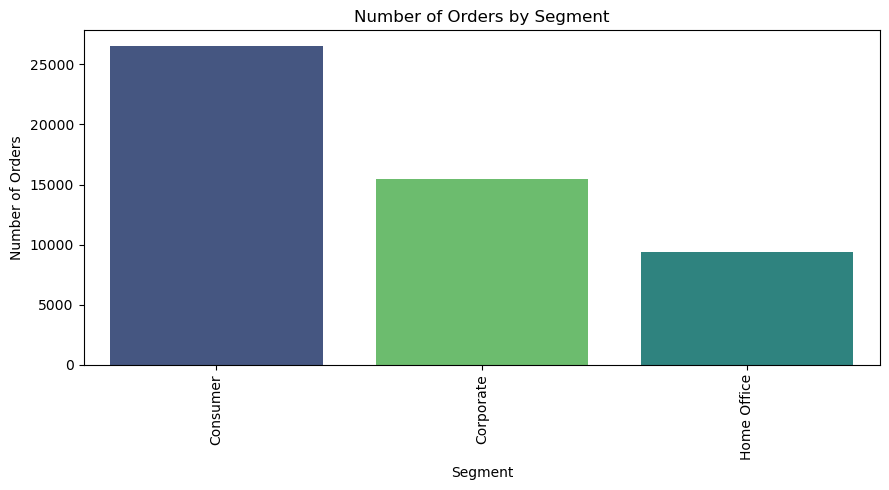

In [87]:
plt.figure(figsize=(9,5))

order = df["segment"].value_counts().index

sns.countplot(
    data=df,
    x="segment",
    order=order,
    hue="segment",
    palette="viridis",
    legend=False
)

plt.title("Number of Orders by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\242927638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="ship_mode",order=order,palette="viridis")


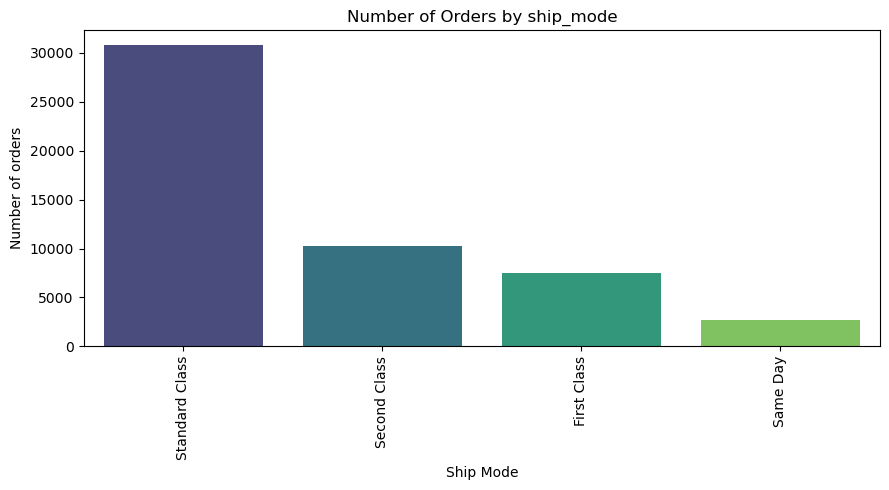

In [88]:
plt.figure(figsize=(9,5))
order=df["ship_mode"].value_counts().index
sns.countplot(data=df,x="ship_mode",order=order,palette="viridis")
plt.title("Number of Orders by ship_mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of orders")
plt.xticks(rotation=90)
plt.tight_layout()

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\3975540894.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="category",order=order,palette="plasma")


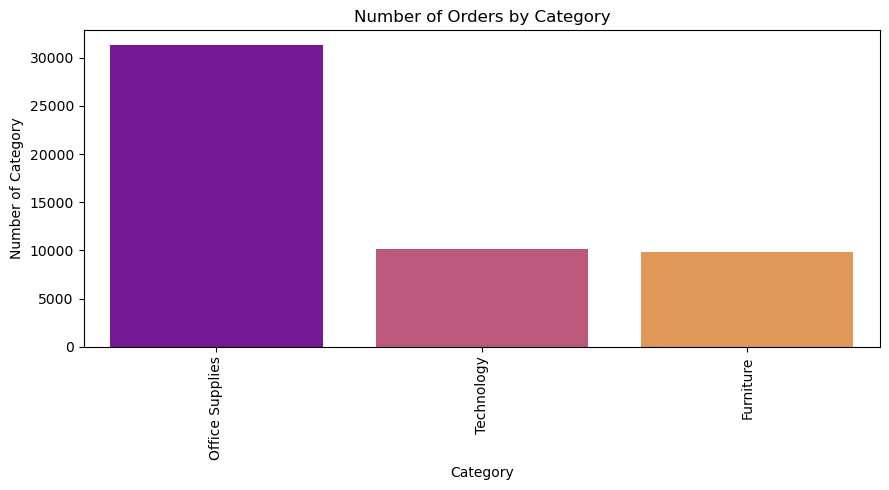

In [89]:
plt.figure(figsize=(9,5))
order=df["category"].value_counts().index
sns.countplot(data=df,x="category",order=order,palette="plasma")
plt.title("Number of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\3963924294.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="sub_category",order=order,palette="inferno")


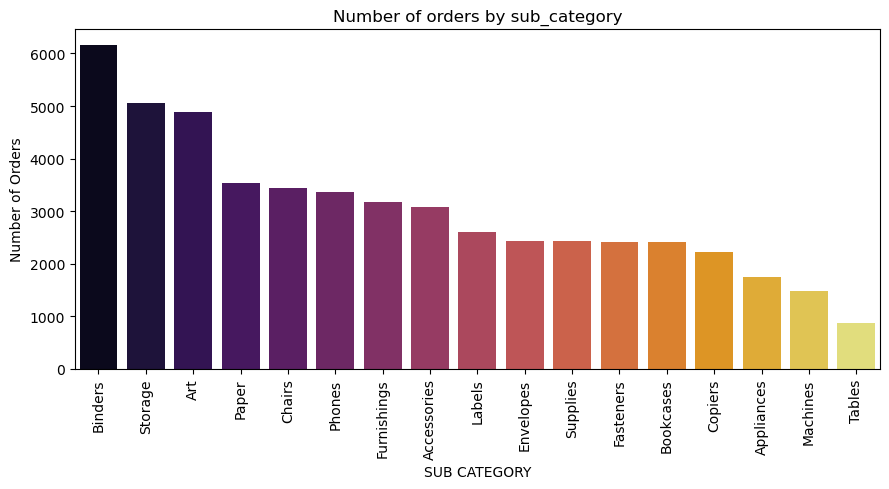

In [90]:
plt.figure(figsize=(9,5))
order=df["sub_category"].value_counts().index
sns.countplot(data=df,x="sub_category",order=order,palette="inferno")
plt.title("Number of orders by sub_category")
plt.xlabel("SUB CATEGORY")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\2582071909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="market",order=order,palette="magma")


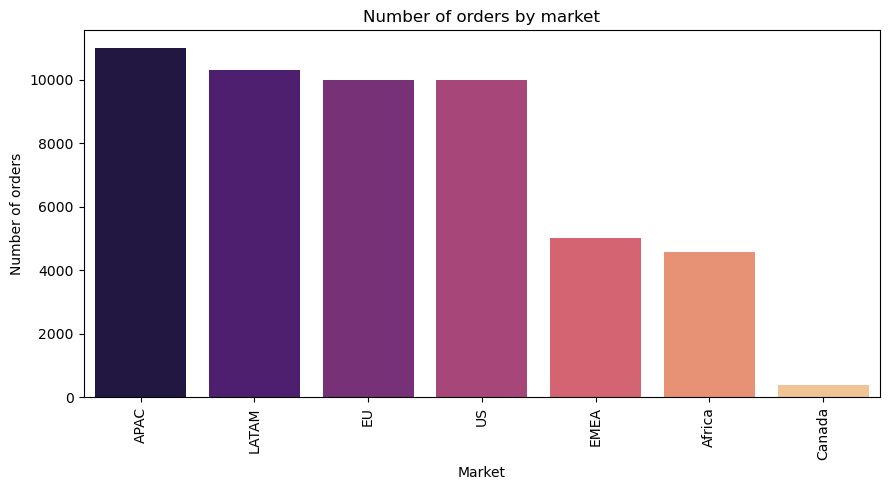

In [91]:
plt.figure(figsize=(9,5))
order=df["market"].value_counts().index
sns.countplot(data=df,x="market",order=order,palette="magma")
plt.title("Number of orders by market")
plt.xlabel("Market")
plt.ylabel("Number of orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\597231290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="region",order=order,palette="cividis")


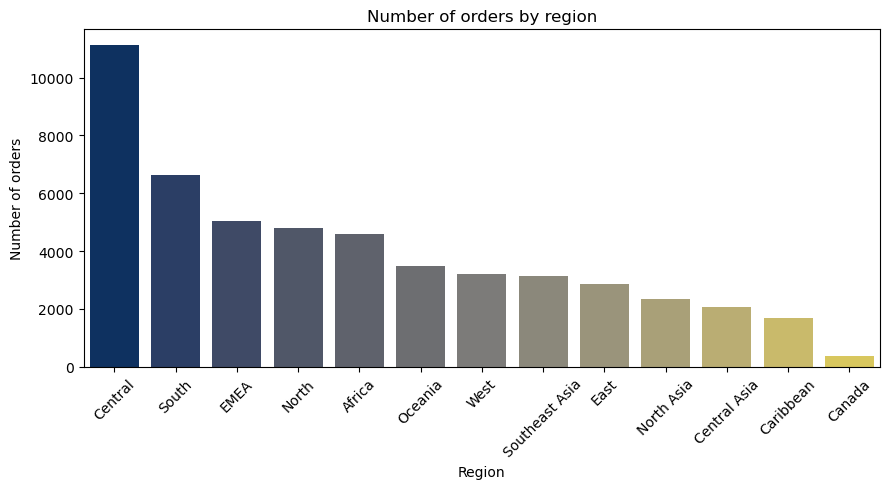

In [92]:
plt.figure(figsize=(9,5))
order=df["region"].value_counts().index
sns.countplot(data=df,x="region",order=order,palette="cividis")
plt.title("Number of orders by region")
plt.xlabel("Region")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\232661283.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="order_priority",order=order,palette="coolwarm")


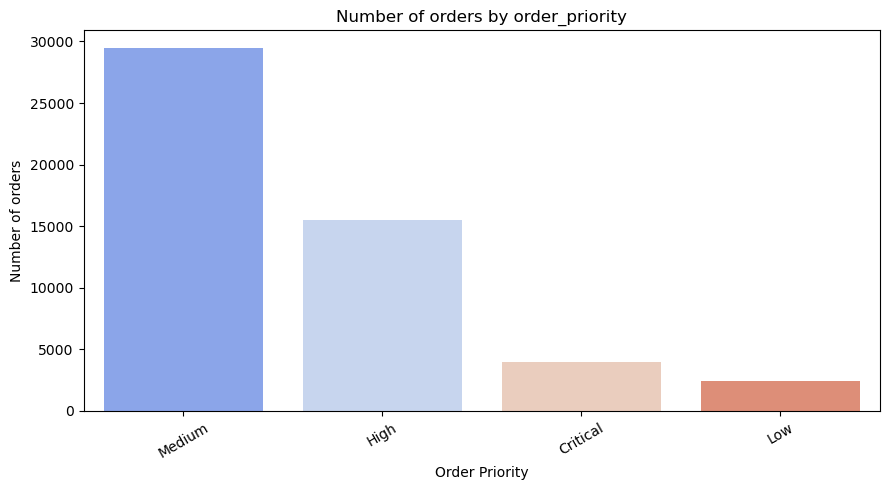

In [93]:
plt.figure(figsize=(9,5))
order=df["order_priority"].value_counts().index
sns.countplot(data=df,x="order_priority",order=order,palette="coolwarm")
plt.title("Number of orders by order_priority")
plt.xlabel("Order Priority")
plt.ylabel("Number of orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

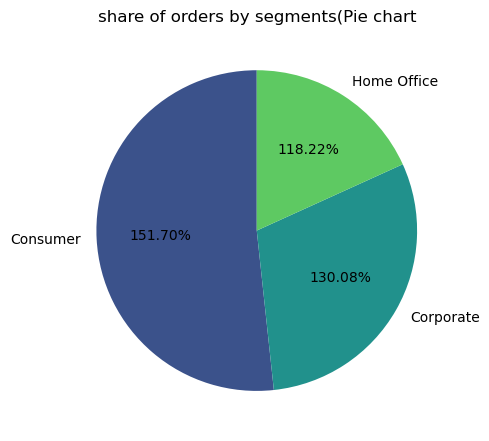

In [94]:
segment_counts=df["segment"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(segment_counts,labels=segment_counts.index,autopct="1%.2f%%",
startangle=90,colors=sns.color_palette("viridis",len(segment_counts)))
plt.title("share of orders by segments(Pie chart")
plt.tight_layout()
plt.show()

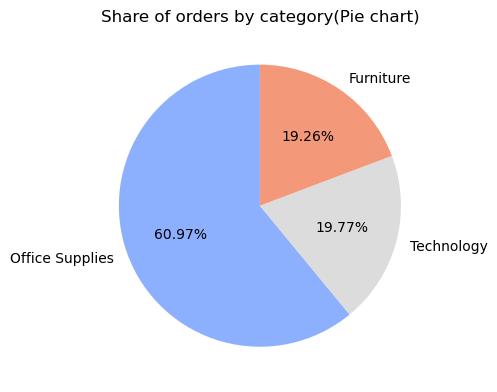

In [95]:
category_counts=df["category"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(category_counts,labels=category_counts.index,autopct="%1.2f%%",startangle=90,
        colors=sns.color_palette("coolwarm",len(category_counts)))
plt.title("Share of orders by category(Pie chart)")
plt.tight_layout()
plt.show()

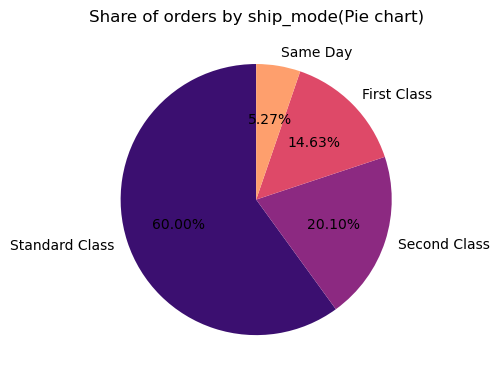

In [96]:
ship_mode_counts=df["ship_mode"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(ship_mode_counts,labels=ship_mode_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("magma",len(ship_mode_counts)))
plt.title("Share of orders by ship_mode(Pie chart)")
plt.tight_layout()
plt.show()

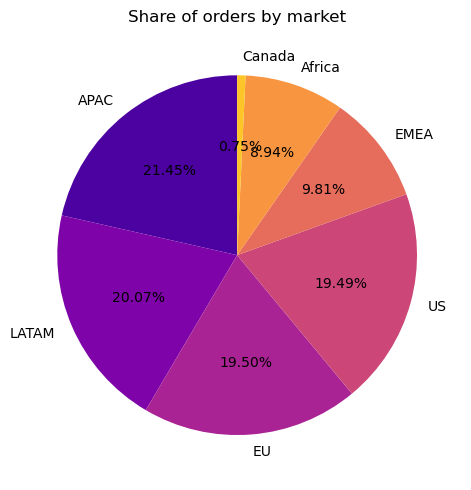

In [97]:
market_counts=df["market"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(market_counts,labels=market_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("plasma",len(market_counts)))
plt.title("Share of orders by market")
plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'titlt'

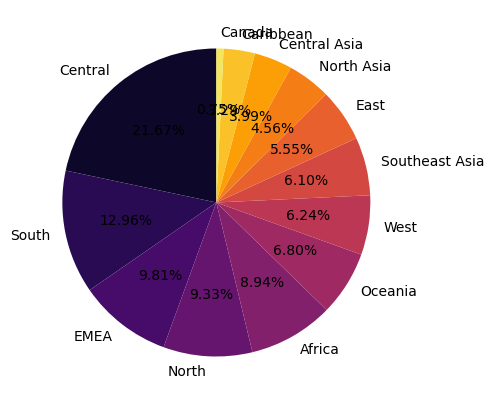

In [98]:
region_counts=df["region"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(region_counts,labels=region_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("inferno",len(region_counts)))
plt.titlt("Share of orders by region")
plt.tight_layout()
plt.show()

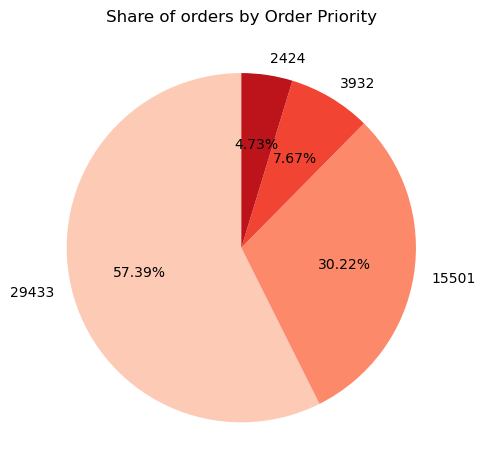

In [99]:
order_priority_counts=df["order_priority"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(order_priority_counts,labels=order_priority_counts,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("Reds",len(order_priority_counts)))
plt.title("Share of orders by Order Priority")
plt.tight_layout()
plt.show()

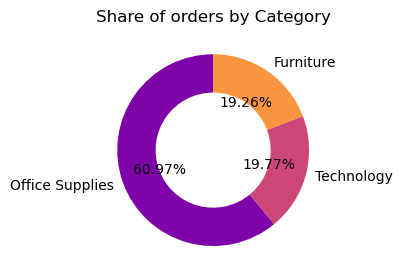

In [101]:
category_counts=df["category"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(category_counts,labels=category_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("plasma",len(category_counts)),
       wedgeprops=dict(width=0.4))
plt.title("Share of orders by Category")
plt.tight_layout()
plt.show()

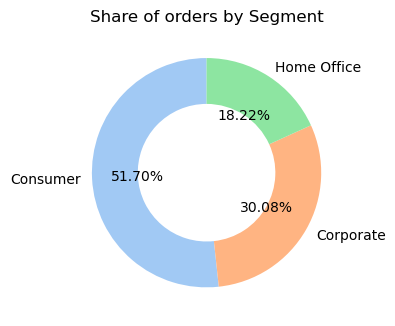

In [102]:
segment_counts=df["segment"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(segment_counts,labels=segment_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("pastel",len(segment_counts)),
       wedgeprops=dict(width=0.4))
plt.title("Share of orders by Segment")
plt.tight_layout()
plt.show()

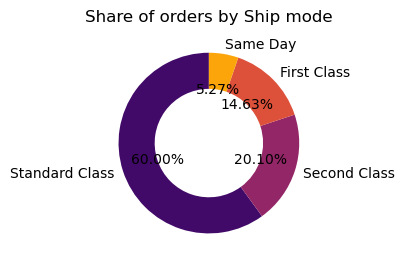

In [103]:
ship_mode_counts=df["ship_mode"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(ship_mode_counts,labels=ship_mode_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("inferno",len(ship_mode_counts)),
        wedgeprops=dict(width=0.4))
plt.title("Share of orders by Ship mode")
plt.tight_layout()
plt.show()

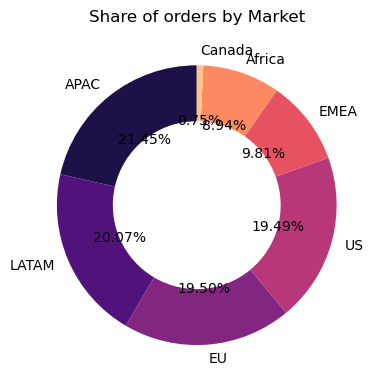

In [104]:
market_counts=df["market"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(market_counts,labels=market_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("magma",len(market_counts)),
       wedgeprops=dict(width=0.4))
plt.title("Share of orders by Market")
plt.tight_layout()
plt.show()

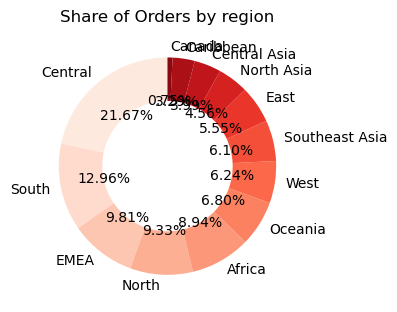

In [105]:
region_counts=df["region"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(region_counts,labels=region_counts.index ,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("Reds",len(region_counts)),
        wedgeprops=dict(width=0.4))
plt.title("Share of Orders by region")
plt.tight_layout()
plt.show()

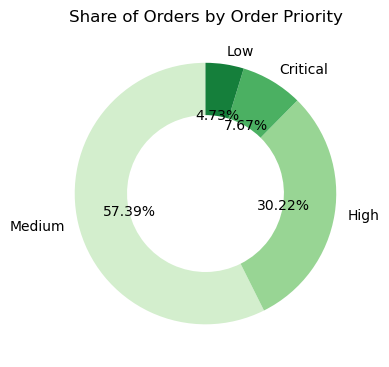

In [106]:
order_priority_counts=df["order_priority"].value_counts()
plt.figure(figsize=(4,4))
plt.pie(order_priority_counts,labels=order_priority_counts.index,autopct="%1.2f%%",
       startangle=90,colors=sns.color_palette("Greens",len(order_priority_counts)),
       wedgeprops=dict(width=0.4))
plt.title("Share of Orders by Order Priority")
plt.tight_layout()
plt.show()

In [107]:


# Global plot style settings for clean, consistent visuals
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\4047353096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="category" , y="sales", palette="Set2")


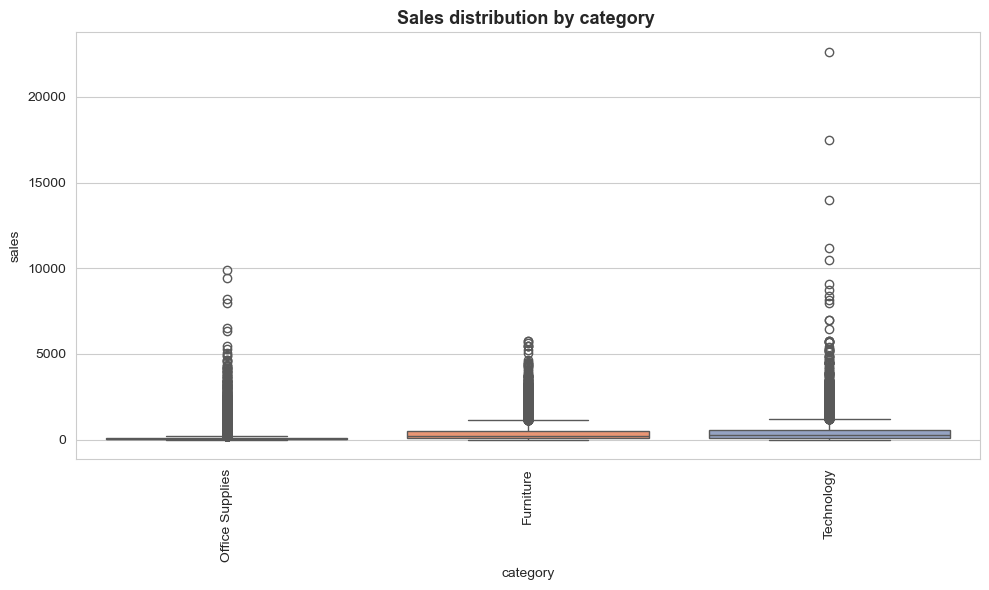

In [109]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="category" , y="sales", palette="Set2")
plt.title("Sales distribution by category ")
plt.xlabel("category")
plt.ylabel("sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_27064\985369315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="ship_mode" , y="shipping_cost", palette="Set2")


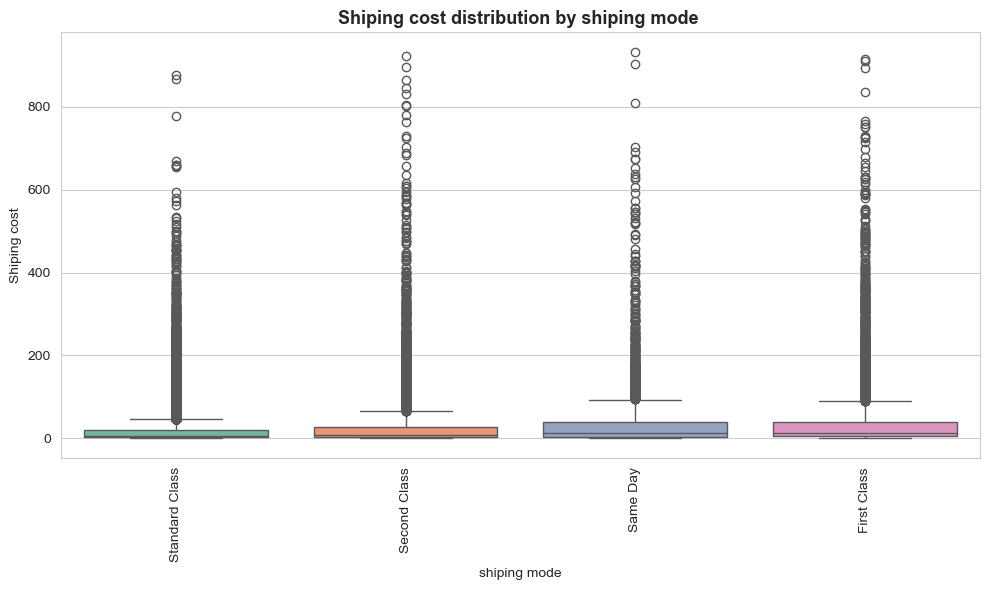

In [111]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="ship_mode" , y="shipping_cost", palette="Set2")
plt.title("Shiping cost distribution by shiping mode ")
plt.xlabel("shiping mode")
plt.ylabel("Shiping cost")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
#region + profit
plt.figure(figsize=(9,5))
sns.barplot(x=

In [ ]:
segment + sales

jgkj

##### 